In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from opacus import PrivacyEngine
import gc

transform = transforms.Compose([
    transforms.ToTensor(),  
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)


In [2]:
print(train_loader.dataset.data.shape)

torch.Size([60000, 28, 28])


MODEL

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class mnist(nn.Module):
    def __init__(self):
        super(mnist, self).__init__()
        self.conv1 = nn.Conv2d(1,6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2,  stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tanh2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tanh2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 120)  # Flatten the tensor
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x

model = mnist()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
gc.collect()

privacy_engine = PrivacyEngine()
    

/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


In [4]:
epochs_2 = 15
train_losses_2 = []
train_accuracies_2 = []
test_losses_2 = []
test_accuracies_2 = []
model.train()
target_delta = 1e-5
model, optimizer, train_loader_private = privacy_engine.make_private_with_epsilon(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    epochs=10,
    target_epsilon=0.2,
    target_delta=target_delta,
    max_grad_norm=0.1,
)
for epoch in range(epochs_2):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/{epochs_2}]')
    print("Training loss", (running_loss / total))
    train_losses_2.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies_2.append(correct * 100 / total)
    gc.collect()

    epsilon = privacy_engine.get_epsilon(delta=target_delta)
    print(f"Privacy Budget (epsilon, delta): ({epsilon:.2f}, {target_delta})")

    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss / total))
    test_losses_2.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies_2.append(correct * 100 / total)

    gc.collect()
    model.eval()
    correct = 0
    total = 0
    eval_loss = 0.0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            eval_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

print(f"Test Loss: {eval_loss / total:.4f}, Accuracy: {100 * correct / total:.2f}%")


/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


Epoch [1/15]
Training loss 2.227330206553141
Training accuracy 38.041666666666664 %
Privacy Budget (epsilon, delta): (0.06, 1e-05)
Testing loss 13.363981239318848
Testing accuracy 65.69 %
Epoch [2/15]
Training loss 1.6472105475743613
Training accuracy 64.97 %
Privacy Budget (epsilon, delta): (0.09, 1e-05)
Testing loss 9.883263285446168
Testing accuracy 65.49 %
Epoch [3/15]
Training loss 1.091087927563985
Training accuracy 66.76833333333333 %
Privacy Budget (epsilon, delta): (0.11, 1e-05)
Testing loss 6.5465275653839115
Testing accuracy 68.65 %
Epoch [4/15]
Training loss 0.8922217425982157
Training accuracy 69.76833333333333 %
Privacy Budget (epsilon, delta): (0.12, 1e-05)
Testing loss 5.353330455589294
Testing accuracy 73.91 %
Epoch [5/15]
Training loss 0.7467674463907877
Training accuracy 75.015 %
Privacy Budget (epsilon, delta): (0.14, 1e-05)
Testing loss 4.480604678344727
Testing accuracy 78.14 %
Epoch [6/15]
Training loss 0.6617648884455363
Training accuracy 78.32666666666667 %
Pri

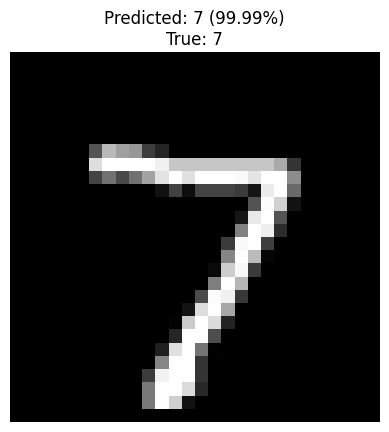

In [5]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

model.eval()
N = 1
examples_shown = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)  # convert logits to probabilities
        confidences, predictions = torch.max(probs, 1)

        for i in range(inputs.size(0)):
            image = inputs[i].squeeze().numpy()  # remove channel dim
            true_label = labels[i].item()
            pred_label = predictions[i].item()
            confidence = confidences[i].item()

            # Plot the image
            plt.imshow(image, cmap='gray')
            plt.title(f"Predicted: {pred_label} ({confidence*100:.2f}%)\nTrue: {true_label}")
            plt.axis('off')
            plt.show()

            examples_shown += 1
            if examples_shown >= N:
                break
        if examples_shown >= N:
            break


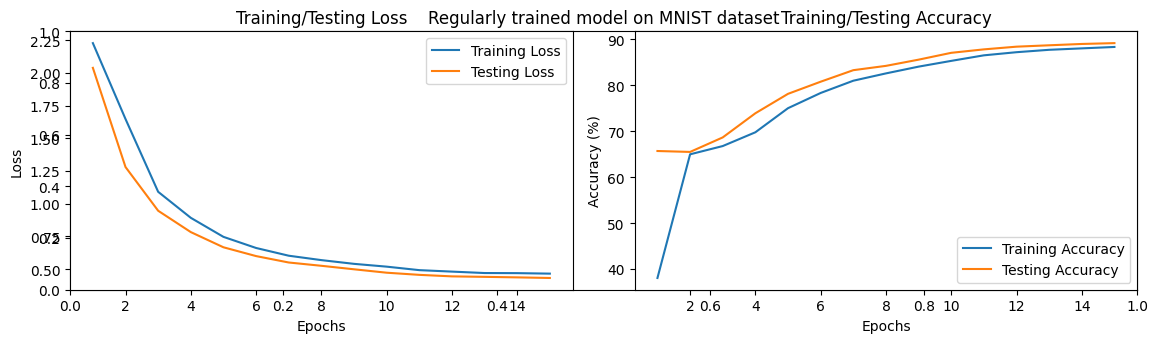

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.title('Regularly trained model on MNIST dataset')
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs_2 + 1), train_losses_2, label='Training Loss')
plt.plot(range(1, epochs_2 + 1), test_losses_2, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training/Testing Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs_2 + 1), train_accuracies_2, label='Training Accuracy')
plt.plot(range(1, epochs_2 + 1), test_accuracies_2, label='Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training/Testing Accuracy')
plt.legend()

plt.tight_layout()
plt.show()